# 04. SIR sweep — five-step procedure unrolled

This notebook walks through the five-step SIR procedure of
Section 2.3 of the manuscript, one step per code cell. The same
algorithm is in `scripts/run_sir_sweep.py` for batch execution.

**Procedure:**

- **Stage 1 (prior cache).** Forward-simulate every prior
  parameter sample on the storm. *Done in `run_prior_mc.py` and
  re-loaded here.*
- **Stage 2 (SIR sweep).** For each (window, scenario):
    - Step 1. Read prior simulations.
    - Step 2. SIS log-likelihood under Eq. 6.
    - Step 3. Effective sample size $N_{eff} = 1 / \sum w_i^2$.
    - Step 4. Systematic resampling (Kitagawa, 1996).
    - Step 5. Gaussian perturbation + re-simulation.

In [3]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from uhf_sir import Model

## Stage 1: load the prior cache

The Stage 1 prior was built by `scripts/run_prior_mc.py`. We load
the working ensemble (500 behavioural particles) and their cached
forward simulations. The full sweep uses N=500; for this demo we
use a subset to keep cell run time manageable.

In [4]:
# Load the SIR sweep output (which also stored the Stage 1 prior)
d = np.load("../outputs/sir_sweep_storm33_15p.npz", allow_pickle=True)

param_names = [str(p) for p in d["param_names"]]
N           = int(d["N"]) if "N" in d.files else int(d["n_ensemble"])
prior       = pd.DataFrame(d["prior_params"], columns=param_names)
Q_prior     = d["prior_Q"]                                           # (N, T)
C_prior     = d["prior_C"]                                           # (N, T)

# Observations on the hourly grid
Q_obs       = d["Q_obs"]                                             # m^3/s
C_obs_h     = d["C_obs_hourly"] if "C_obs_hourly" in d.files else d["C_obs"]
t_hr        = d["t_hr"]                                              # hr from rain start
in_scoring  = d["scoring_mask"]                                      # bool mask
sigma_Q     = float(d["sigma_Q"])                                    # m^3/s
sigma_C     = float(d["sigma_C"])                                    # mg/L

print(f"N (working ensemble): {N}")
print(f"sigma_Q = {sigma_Q:.3f} m^3/s,  sigma_C = {sigma_C:.3f} mg/L")

N (working ensemble): 500
sigma_Q = 0.375 m^3/s,  sigma_C = 0.800 mg/L


## Visualise the prior simulation envelope

Every behavioural particle hits NSE_Q ≥ 0.3 in the scoring window,
so the streamflow envelope brackets the observed hydrograph. The
chloride envelope is much wider because chloride was not used to
filter the prior.

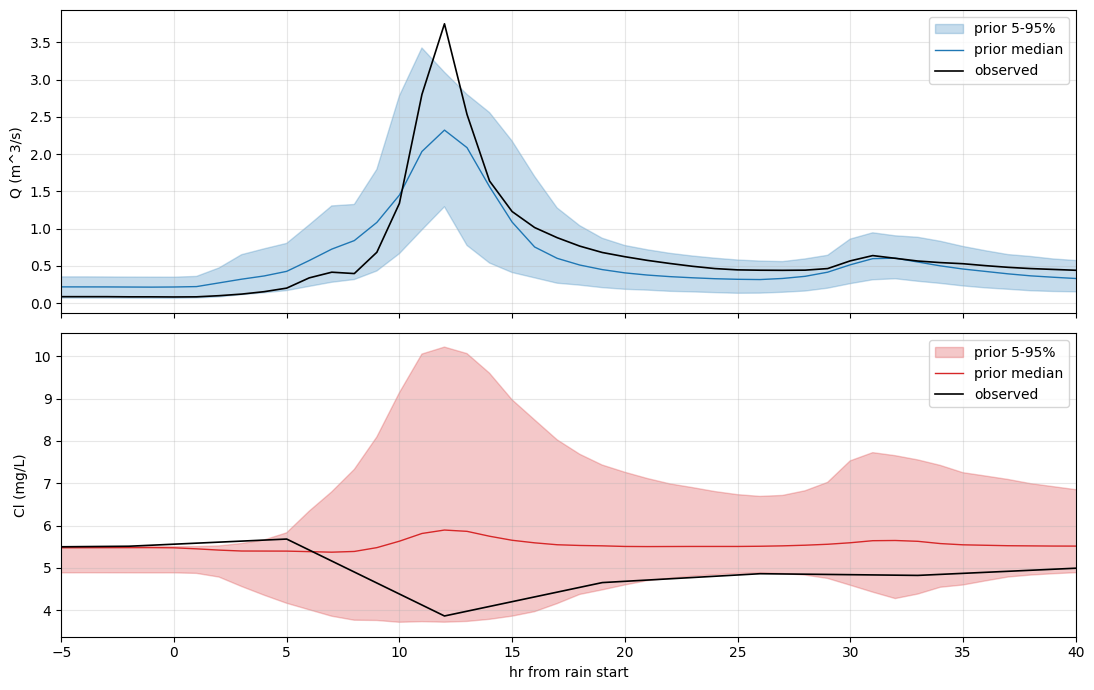

In [5]:
fig, (ax_Q, ax_C) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Streamflow envelope
q05, q50, q95 = np.percentile(Q_prior, [5, 50, 95], axis=0)
ax_Q.fill_between(t_hr, q05, q95, color="C0", alpha=0.25, label="prior 5-95%")
ax_Q.plot(t_hr, q50, color="C0", lw=1.0, label="prior median")
ax_Q.plot(t_hr, Q_obs, color="black", lw=1.2, label="observed")
ax_Q.set_ylabel("Q (m^3/s)")
ax_Q.legend(); ax_Q.grid(alpha=0.3)

# Chloride envelope
c05, c50, c95 = np.percentile(C_prior, [5, 50, 95], axis=0)
ax_C.fill_between(t_hr, c05, c95, color="C3", alpha=0.25, label="prior 5-95%")
ax_C.plot(t_hr, c50, color="C3", lw=1.0, label="prior median")
ax_C.plot(t_hr, C_obs_h, color="black", lw=1.2, label="observed")
ax_C.set_ylabel("Cl (mg/L)")
ax_C.set_xlabel("hr from rain start")
ax_C.set_xlim(-5, 40)
ax_C.legend(); ax_C.grid(alpha=0.3)

plt.tight_layout()

## Step 2: SIS log-likelihood (Eq. 6)

$$\ln L_i \;=\; -\frac{1}{2} \sum_{t \in W} \Big[
   \frac{(Q_{s,i}(t) - Q_o(t))^2}{\sigma_Q^2}
 + \frac{(C_{s,i}(t) - C_o(t))^2}{\sigma_C^2} \Big]$$

The chloride term is dropped under the Q-only scenario. We pick
window $t_{end} = 10$ h and scenario Q+Cl as a representative case.

In [6]:
# Choose a representative window and scenario
t_end_hr = 10.0                                                      # window end [hr]
use_Q    = True                                                      # Q likelihood term on
use_C    = True                                                      # Cl likelihood term on

# Initialise log-weights and validity mask
log_w  = np.zeros(N)                                                 # log-weight per particle
valid  = ~(np.isnan(Q_prior[:, 0]) | np.isnan(C_prior[:, 0]))        # valid particles
n_used = 0                                                           # obs points used

# Sum Gaussian log-likelihood over time steps inside the window
for t in range(len(t_hr)):
    if not in_scoring[t]:
        continue
    if t_hr[t] > t_end_hr:
        break
    if use_Q:
        diff_Q = (Q_obs[t] - Q_prior[:, t]) ** 2
        log_w[valid] -= 0.5 * diff_Q[valid] / sigma_Q ** 2            # Q term
    if use_C:
        diff_C = (C_obs_h[t] - C_prior[:, t]) ** 2
        log_w[valid] -= 0.5 * diff_C[valid] / sigma_C ** 2            # Cl term
    n_used += 1
log_w[~valid] = -1e12                                                # invalid: ignore

print(f"n_used = {n_used} obs points used in the likelihood")
print(f"log_w range: [{log_w.min():.1f}, {log_w.max():.1f}]")

n_used = 11 obs points used in the likelihood
log_w range: [-85.8, -0.8]


### Normalize log-weights to a probability vector

We subtract the maximum log-weight before exponentiating. This is
the standard softmax stabilization: it prevents overflow when
log-weights are large in magnitude.

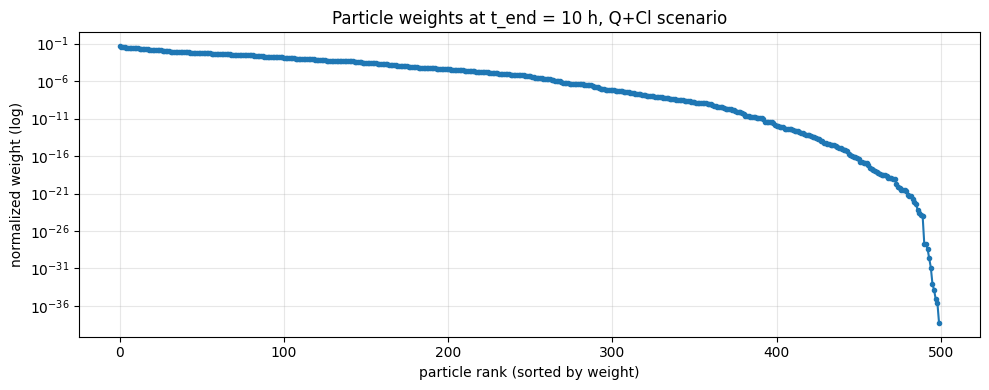

In [7]:
# Subtract max for numerical stability, exponentiate, normalise
log_w -= log_w.max()                                                 # shift so max = 0
w     = np.exp(log_w)
if w.sum() < 1e-300:
    w = np.where(valid, 1.0, 0.0)                                    # fallback: uniform on valid
w /= w.sum()                                                         # normalize to probability

# Plot weight distribution (sorted, log y-axis)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(np.sort(w)[::-1], "o-", ms=3)
ax.set_xlabel("particle rank (sorted by weight)")
ax.set_ylabel("normalized weight (log)")
ax.set_title(f"Particle weights at t_end = {t_end_hr:.0f} h, Q+Cl scenario")
ax.grid(alpha=0.3)
plt.tight_layout()

## Step 3: Effective sample size diagnostic

$$N_{eff} \;=\; \frac{1}{\sum_{i=1}^{N} w_i^2}$$

Equals $N$ when weights are uniform; equals 1 when all weight
concentrates on one particle. The validity threshold of $N_{eff}
\geq 10$ (Doucet & Johansen, 2009) defines the upper end of the
1–10 h interpretation window in Section 3.2.

In [8]:
# Compute N_eff for the chosen window/scenario
N_eff = 1.0 / np.sum(w ** 2)
print(f"N_eff at t_end = {t_end_hr:.0f} h, Q+Cl: {N_eff:.2f} / {N}")

N_eff at t_end = 10 h, Q+Cl: 53.59 / 500


### N_eff across all (window, scenario) combinations

Loop over the 14 windows × 2 scenarios used in the manuscript
(Section 3.2, Figure 4 inset B). Q+Cl decays faster than Q-only
because the joint likelihood is sharper.

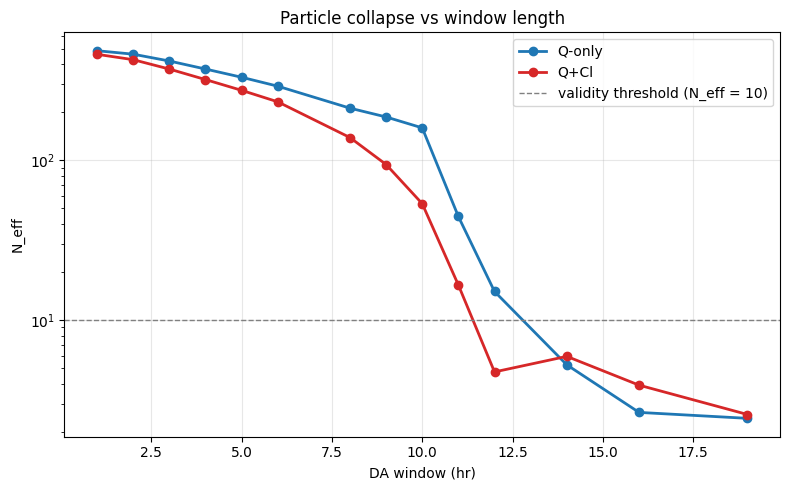

In [9]:
SNAPSHOTS = [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 14, 16, 19]          # hr from rain start

def neff_at(t_end, use_C):
    """Inline helper: compute N_eff for one (window, scenario)."""
    log_w  = np.zeros(N)
    valid  = ~(np.isnan(Q_prior[:, 0]) | np.isnan(C_prior[:, 0]))
    for t in range(len(t_hr)):
        if not in_scoring[t]: continue
        if t_hr[t] > t_end:   break
        log_w[valid] -= 0.5 * (Q_obs[t] - Q_prior[valid, t]) ** 2 / sigma_Q ** 2
        if use_C:
            log_w[valid] -= 0.5 * (C_obs_h[t] - C_prior[valid, t]) ** 2 / sigma_C ** 2
    log_w[~valid] = -1e12
    log_w -= log_w.max()
    w = np.exp(log_w);  w /= w.sum()
    return 1.0 / np.sum(w ** 2)

# Compute N_eff for both scenarios at every snapshot
neff_q  = [neff_at(T, use_C=False) for T in SNAPSHOTS]
neff_qc = [neff_at(T, use_C=True)  for T in SNAPSHOTS]

# Plot N_eff vs window length
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(SNAPSHOTS, neff_q,  "o-", color="C0", lw=2, label="Q-only")
ax.semilogy(SNAPSHOTS, neff_qc, "o-", color="C3", lw=2, label="Q+Cl")
ax.axhline(10, color="gray", ls="--", lw=1, label="validity threshold (N_eff = 10)")
ax.set_xlabel("DA window (hr)"); ax.set_ylabel("N_eff")
ax.set_title("Particle collapse vs window length")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## Step 4: Systematic resampling (Kitagawa, 1996)

Single uniform offset, rest is deterministic. Lower Monte Carlo
variance than multinomial resampling (Douc et al., 2005). The
$N$ resampled positions are spaced evenly along the cumulative
weight distribution.

In [10]:
# Per-step RNG (reproducible across windows/scenarios)
SEED = 12345
rng  = np.random.default_rng(SEED + hash(f"{int(t_end_hr):02d}h__Q+Cl") % (2 ** 31))

# Systematic resampling: single uniform offset, evenly-spaced positions
positions = (np.arange(N) + rng.uniform()) / N                       # in (0, 1)
cumw      = np.cumsum(w)
idx_resampled = np.clip(np.searchsorted(cumw, positions), 0, N - 1)  # resampled indices

# How many copies of each original particle made it into the resample?
unique, counts = np.unique(idx_resampled, return_counts=True)
print(f"Unique particles surviving: {len(unique)} / {N}")
print(f"Most-copied particle: {counts.max()} copies")
print(f"Particles dropped:    {N - len(unique)}")

Unique particles surviving: 119 / 500
Most-copied particle: 23 copies
Particles dropped:    381


### Visualise: prior $V_{soil}$ vs resampled $V_{soil}$

Resampling concentrates particles on the high-weight regions of
parameter space. We pick $V_{soil}$ here because it shows the
directional posterior shift discussed in Section 3.3 (lower-tail
mass drops from 59% to 24% under Q+Cl).

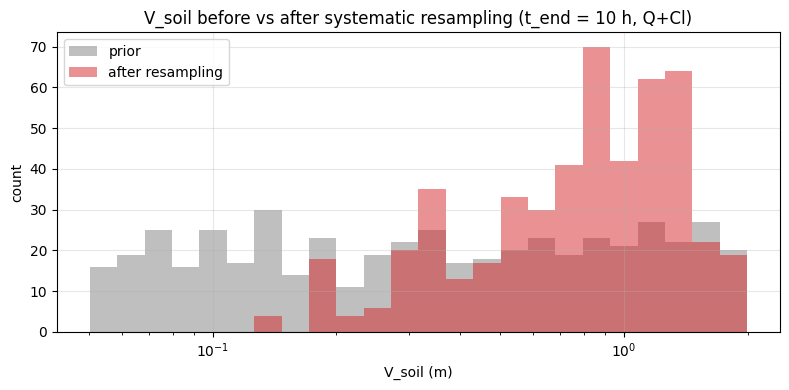

In [11]:
# Pick V_soil for visualisation (log-space for clarity)
i_v = param_names.index("V_soil")
V_prior     = prior["V_soil"].values
V_resampled = prior.iloc[idx_resampled]["V_soil"].values

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(np.log10(V_prior.min()), np.log10(V_prior.max()), 25)
ax.hist(V_prior,     bins=bins, alpha=0.5, color="gray", label="prior")
ax.hist(V_resampled, bins=bins, alpha=0.5, color="C3",   label="after resampling")
ax.set_xscale("log")
ax.set_xlabel("V_soil (m)"); ax.set_ylabel("count")
ax.set_title(f"V_soil before vs after systematic resampling (t_end = {t_end_hr:.0f} h, Q+Cl)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## Step 5: Gaussian perturbation

After systematic resampling, every duplicate particle is
identical — re-simulating them all would waste computation. We
add Gaussian jitter (Moradkhani et al., 2005) to keep the
ensemble diverse, with std equal to $\phi = 0.05$ of the prior std.

Log-space parameters ($K_s$, $K_{ex}$, $\tau_{drain}$, $S_{max}$)
are perturbed in log space; others in linear space. Values are
clipped to prior bounds.

In [12]:
PERTURB  = 0.05                                                      # phi: jitter / prior std
LOG_PARS = ("K_s", "K_ex", "tau_drain", "S_max")

# Pre-compute prior std and bounds (log-space for the four log params)
prior_std_lin = prior.std(axis=0).to_dict()
prior_std_log = {p: float(np.std(np.log(prior[p].values)))
                 for p in LOG_PARS if (prior[p] > 0).all()}
prior_lo = prior.min(axis=0).to_dict()
prior_hi = prior.max(axis=0).to_dict()

# Build the perturbed posterior ensemble
new_df = prior.iloc[idx_resampled].reset_index(drop=True).copy()
for p in param_names:
    if p in LOG_PARS and prior_lo[p] > 0:
        log_v = np.log(new_df[p].values.astype(float))
        if prior_std_log.get(p, 0) > 0:
            noise = rng.normal(0, PERTURB * prior_std_log[p], N)
            log_v = log_v + noise                                    # log-space jitter
        new_df[p] = np.exp(np.clip(log_v,
                                     np.log(prior_lo[p]),
                                     np.log(prior_hi[p])))
    else:
        if prior_std_lin[p] > 0:
            noise = rng.normal(0, PERTURB * prior_std_lin[p], N)    # linear-space jitter
            new_df[p] = np.clip(new_df[p].values + noise,
                                 prior_lo[p], prior_hi[p])

print(f"Perturbed posterior ensemble: {len(new_df)} particles")
print(f"V_soil mean after perturbation: {new_df['V_soil'].mean():.3f} m"
      f"  (prior mean: {prior['V_soil'].mean():.3f} m)")

Perturbed posterior ensemble: 500 particles
V_soil mean after perturbation: 0.869 m  (prior mean: 0.558 m)


### Visualise: identifiable parameters before/after one full SIR step

Show prior, resampled (no perturbation), and perturbed marginals
side by side for the three chloride-identifiable parameters
($\alpha_{soil}$, $V_{soil}$, $Q_{threshold}$). Perturbation
broadens the resampled distribution slightly, restoring diversity
without abandoning the posterior shape.

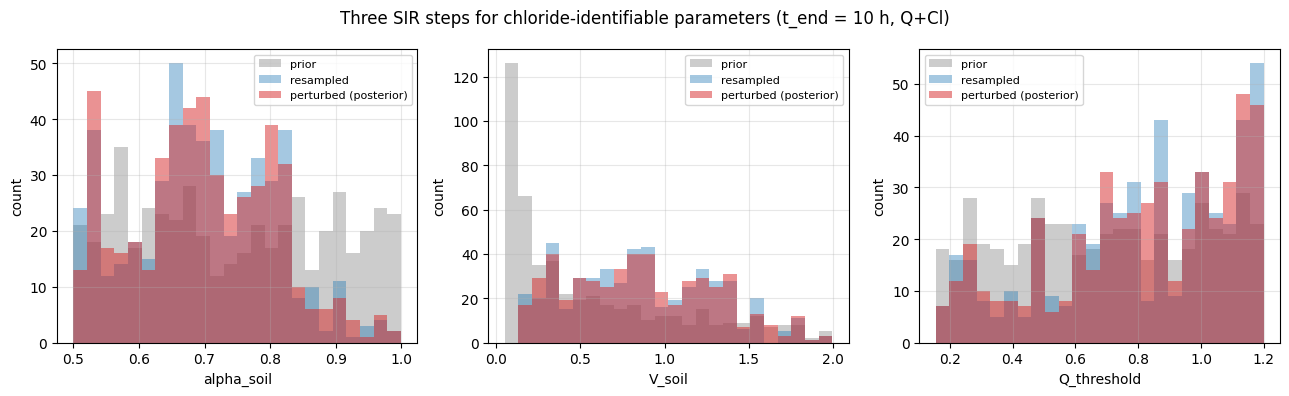

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, p in zip(axes, ["alpha_soil", "V_soil", "Q_threshold"]):
    pr = prior[p].values
    rs = prior.iloc[idx_resampled][p].values
    pt = new_df[p].values
    bins = np.linspace(pr.min(), pr.max(), 25)
    ax.hist(pr, bins=bins, alpha=0.4, color="gray", label="prior")
    ax.hist(rs, bins=bins, alpha=0.4, color="C0",   label="resampled")
    ax.hist(pt, bins=bins, alpha=0.5, color="C3",   label="perturbed (posterior)")
    ax.set_xlabel(p); ax.set_ylabel("count")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f"Three SIR steps for chloride-identifiable parameters (t_end = {t_end_hr:.0f} h, Q+Cl)")
plt.tight_layout()

## Putting it together

A full SIR sweep applies steps 2–5 to every (window, scenario)
combination, then re-simulates every perturbed particle through
the forward model to evaluate the posterior streamflow and
chloride trajectories.

Re-simulation is the most expensive step (~1.5 s per particle
× 500 × 28 combinations ≈ 6 hours single-thread, ~45 min on
8 cores). It is run by `scripts/run_sir_sweep.py`; the result is
the NPZ already loaded above.

See `notebooks/05_results_and_figures.ipynb` for posterior
envelopes, the IQR-reduction heatmap (Figure 4), and the
$V_{soil}$ tertile decomposition (Figure D1).